In [1]:
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;
import gysela_utilities as gys_utils;

# Styling.
plt.style.use("bmh");

In [2]:
# Test inputs - delete when done!
directory_path = "C:/Workspace/NSCC/local copies/raw_output_data/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3";
data_arrays = reader.fetch_phi2D_data(directory_path, parallelise = False);
dt_diag = reader.fetch_dt_diag(directory_path);
jacobian_dictionary = reader.fetch_jacobian(directory_path);
aspect_ratio = reader.fetch_aspect_ratio(directory_path);
safety_factor = reader.fetch_safety_factor_flat(directory_path);

Found 1501 files in the directory. Beginning compilation...
Compiled data from 1000 files...
Finished compiling data from all files in the directory.


Calculating flux surface averages...
Calculating instantaneous radial averages...
Plotting Hovmoller diagram...


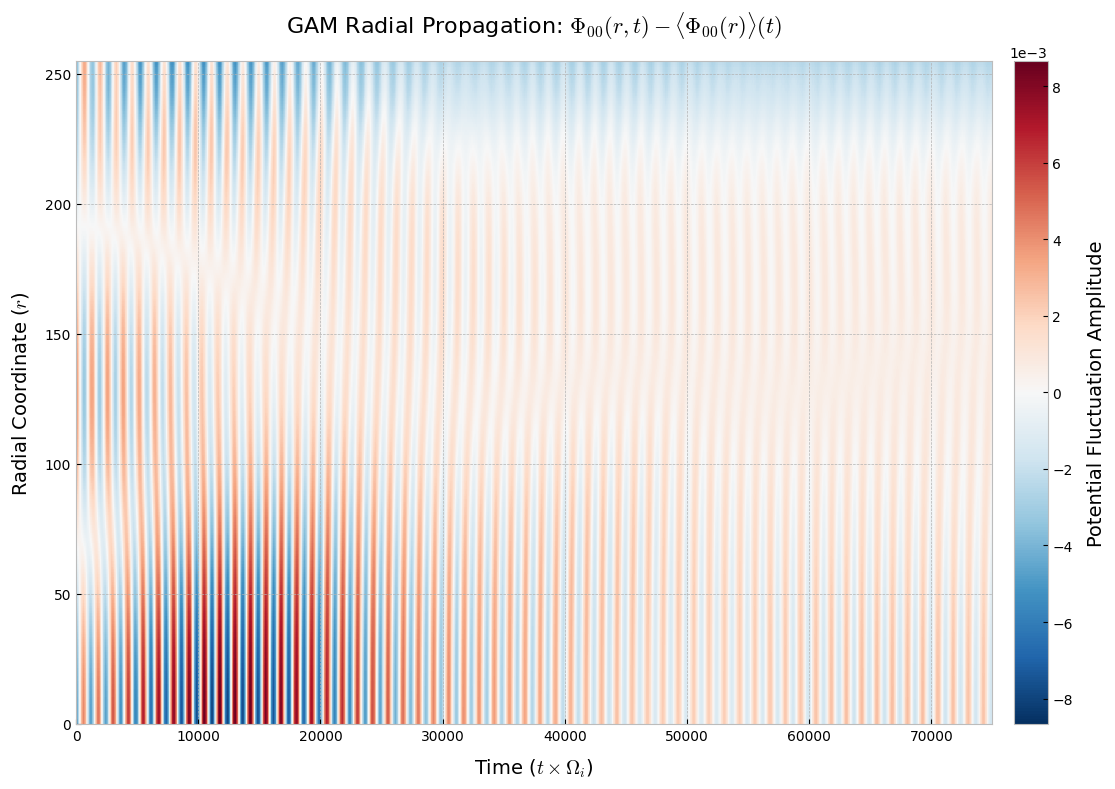

In [ ]:
# TODO: ai slop revise
def plot_gam_hovmoller(phi2D_list, dt_diag, jacobian_dictionary, restart_times=None):
	"""
	Constructs a Time vs. Radius Hovmoller diagram for GAM propagation 
	by dynamically subtracting the spatially averaged n=0 potential.
	"""
	# 1. Generate the FULL (time, r) poloidally-averaged matrix
	print("Calculating flux surface averages...")
	fs_avg_time_series = utils.generate_poloidally_averaged_time_series(
		phi2D_list, jacobian_dictionary, effective_radius=None
	)

	# 2. Calculate the global radial drift (time,)
	print("Calculating instantaneous radial averages...")
	radially_averaged_time_series = gys_utils.radial_average_1D(
		fs_avg_time_series, jacobian_dictionary
	)

	# 3. Isolate the pure GAM signal
	# xarray automatically broadcasts the subtraction over the shared 'time' dimension
	gam_signal_xr = fs_avg_time_series - radially_averaged_time_series
	gam_signal = gam_signal_xr.values

	# Extract coordinates directly from the xarray
	time_steps = gam_signal.shape[0]
	time_axis = np.arange(time_steps) * dt_diag
	
	# Assuming your radial dimension is named 'r'
	r_axis = gam_signal_xr.coords["r"].values 

	# 4. Figure Plotting Logic
	print("Plotting Hovmoller diagram...")
	fig, ax = plt.subplots(figsize=(12, 8))

	# Calculate absolute maximum for symmetric colormap calibration
	vmax = np.abs(gam_signal).max()

	# NOTE: pcolormesh expects the Z array to be shaped (len(Y), len(X)).
	# Since our gam_signal is (time, r), we must transpose it (.T) to (r, time).
	mesh = ax.pcolormesh(
		time_axis, r_axis, gam_signal.T, 
		cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto"
	)

	# 5. Overlay Restart Stitch Lines
	if restart_times is not None:
		for i, t_restart in enumerate(restart_times):
			label = "Restart" if i == 0 else None
			ax.axvline(x=t_restart, color="black", linestyle=(0, (5, 5)), alpha=0.5, label=label)
			ax.text(t_restart, 1.01, f'R{i+1}', transform=ax.get_xaxis_transform(),
					ha='center', va='bottom', fontsize=9, color='black', fontweight='bold')

	# Formatting and Labels
	ax.set_title(r"GAM Radial Propagation: $\Phi_{00}(r, t) - \langle \Phi_{00}(r) \rangle (t)$", fontsize=16, pad=20)
	ax.set_xlabel(r"Time ($t \times \Omega_i$)", fontsize=14, labelpad=10)
	ax.set_ylabel(r"Radial Coordinate ($r$)", fontsize=14, labelpad=10)
	
	# Set y-limits tight to the radial bounds
	ax.set_ylim(r_axis.min(), r_axis.max())
	ax.set_xlim(0, time_axis[-1])

	# Colorbar formatting
	cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
	cbar.set_label(r"Potential Fluctuation Amplitude", fontsize=14, labelpad=10)
	cbar.formatter.set_powerlimits((0, 0))
	cbar.ax.yaxis.get_offset_text().set_fontsize(10)

	if restart_times is not None:
		ax.legend(loc="upper right", framealpha=0.9)

	plt.tight_layout()
	plt.show()

	return fig, ax

plot_gam_hovmoller(data_arrays, dt_diag, jacobian_dictionary);